In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [28]:
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [29]:
# Convert date column to datetime

nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort values

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [30]:
# Compute daily returns for each fund

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [31]:
print(nav_history["daily_return"].isnull().sum())

40


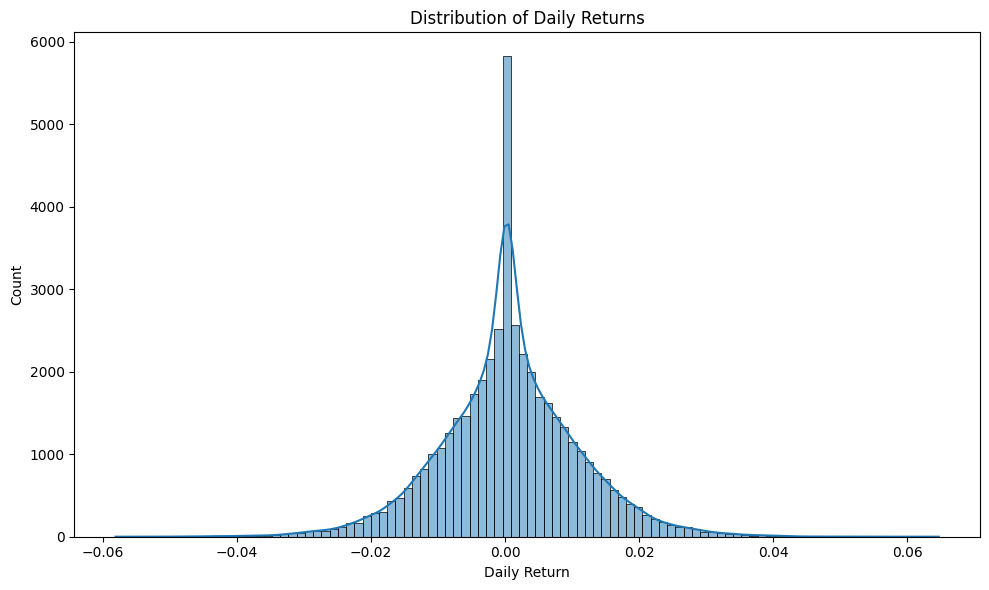

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.tight_layout()

plt.savefig("../charts/daily_return_distribution.png", dpi=300)

plt.show()

In [33]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [34]:
print("Minimum Return :", nav_history["daily_return"].min())

print("Maximum Return :", nav_history["daily_return"].max())

print("Mean Return :", nav_history["daily_return"].mean())

print("Standard Deviation :", nav_history["daily_return"].std())

Minimum Return : -0.058102013949189124
Maximum Return : 0.06471309359097144
Mean Return : 0.0006310517590547712
Standard Deviation : 0.010290414788248919


In [35]:
# CAGR Calculation Function

def calculate_cagr(df, years):
    result = []

    for code, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        if len(group) < 2:
            continue

        start_nav = group.iloc[0]["nav"]
        end_nav = group.iloc[-1]["nav"]

        cagr = ((end_nav / start_nav) ** (1 / years)) - 1

        result.append({
            "amfi_code": code,
            f"CAGR_{years}Y": cagr * 100
        })

    return pd.DataFrame(result)

In [36]:
cagr_1 = calculate_cagr(nav_history, 1)

cagr_3 = calculate_cagr(nav_history, 3)

cagr_5 = calculate_cagr(nav_history, 5)

In [37]:
cagr_table = cagr_1.merge(cagr_3, on="amfi_code")

cagr_table = cagr_table.merge(cagr_5, on="amfi_code")

cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,12.133575,3.891151,2.316843
1,100025,21.155227,6.605772,3.912653
2,100033,218.514228,47.132838,26.074068
3,101206,153.456216,36.343461,20.442730
4,101207,39.949603,11.855469,6.953336


In [38]:
cagr_table = cagr_table.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr_table = cagr_table[
    ["scheme_name", "amfi_code", "CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]
]

cagr_table.head()

,scheme_name,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,12.133575,3.891151,2.316843
1,HDFC Short Term Debt Fund - Regular - Growth,100025,21.155227,6.605772,3.912653
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,218.514228,47.132838,26.074068
3,ABSL Frontline Equity Fund - Regular - Growth,101206,153.456216,36.343461,20.442730
4,ABSL Small Cap Fund - Regular - Growth,101207,39.949603,11.855469,6.953336


In [39]:
top_cagr = cagr_table.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

top_cagr

,scheme_name,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
25,ICICI Pru Midcap Fund - Regular - Growth,120505,248.684056,51.638925,28.376762
21,SBI Small Cap Fund - Regular Plan - Growth,119598,244.043537,50.963214,28.033224
39,DSP Small Cap Fund - Regular - Growth,149324,242.490579,50.735731,27.917430
36,Mirae Asset Tax Saver Fund - Regular - Growth,148569,238.658097,50.171374,27.629860
34,Mirae Asset Large Cap Fund - Regular - Growth,148567,227.781083,48.546114,26.799277
30,Kotak Flexicap Fund - Regular - Growth,120843,227.047809,48.435261,26.742494
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,218.514228,47.132838,26.074068
38,DSP Midcap Fund - Regular - Growth,149323,212.717589,46.234812,25.611807
16,Axis Midcap Fund - Regular - Growth,119094,198.464473,43.978468,24.445309
19,SBI Bluechip Fund - Regular Plan - Growth,119551,174.560913,40.027361,22.384873


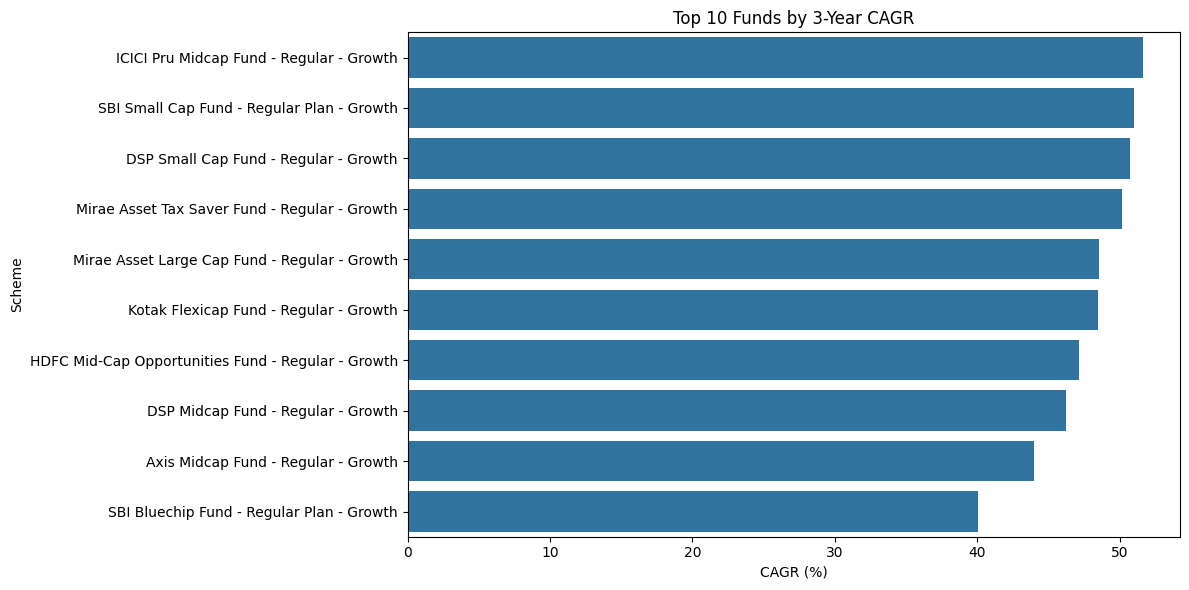

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="CAGR_3Y",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("CAGR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../charts/cagr_comparison.png", dpi=300)

plt.show()

In [41]:
# Risk-free rate (RBI Repo Rate Proxy)

risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

print("Daily Risk Free Rate:", daily_rf)

Daily Risk Free Rate: 0.00025793650793650796


In [42]:
sharpe_results = []

for code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [43]:
sharpe_df = sharpe_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df = sharpe_df[
    ["scheme_name", "amfi_code", "Sharpe_Ratio"]
]

sharpe_df.head()

,scheme_name,amfi_code,Sharpe_Ratio
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,-0.201517
1,HDFC Short Term Debt Fund - Regular - Growth,100025,-0.567095
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,1.093699
3,ABSL Frontline Equity Fund - Regular - Growth,101206,1.027213
4,ABSL Small Cap Fund - Regular - Growth,101207,0.162661


In [45]:
sharpe_df = sharpe_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)



In [46]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,scheme_name_x,amfi_code,Sharpe_Ratio,scheme_name_y,scheme_name
34,Mirae Asset Large Cap Fund - Regular - Growth,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth
30,Kotak Flexicap Fund - Regular - Growth,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth
36,Mirae Asset Tax Saver Fund - Regular - Growth,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth
19,SBI Bluechip Fund - Regular Plan - Growth,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth
25,ICICI Pru Midcap Fund - Regular - Growth,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth
38,DSP Midcap Fund - Regular - Growth,149323,1.132122,DSP Midcap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,Nippon India Large Cap Fund - Regular - Growth,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth,Nippon India Large Cap Fund - Regular - Growth
3,ABSL Frontline Equity Fund - Regular - Growth,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth
24,ICICI Pru Bluechip Fund - Direct - Growth,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Pru Bluechip Fund - Direct - Growth


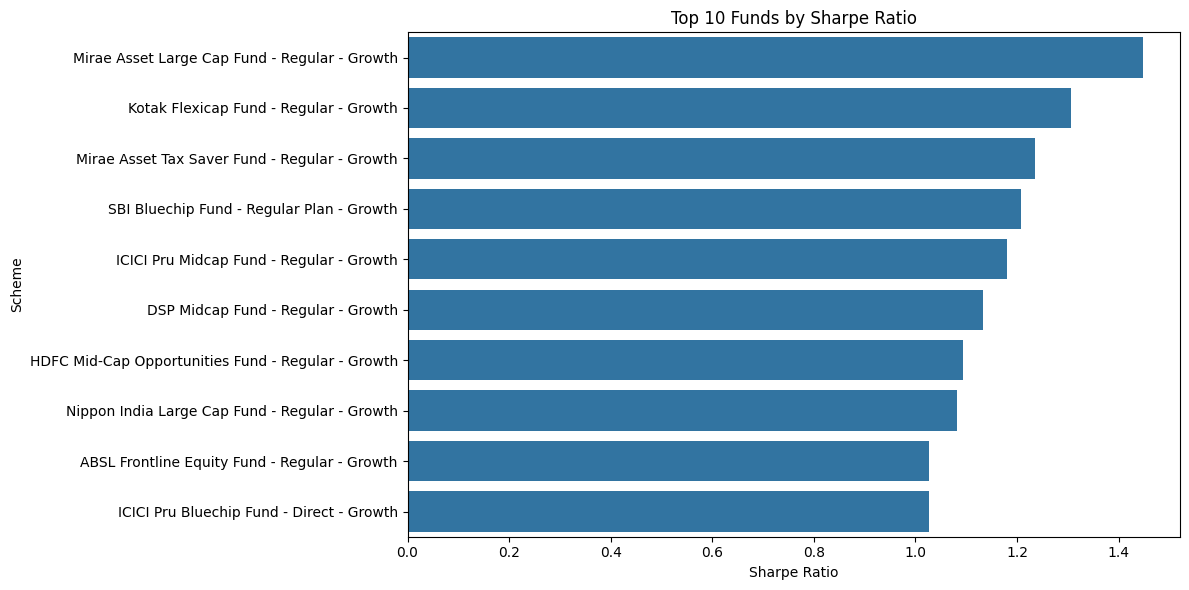

In [47]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="Sharpe_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../charts/sharpe_ratio.png", dpi=300)

plt.show()

In [48]:
sortino_results = []

for code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    downside = returns[returns < 0]

    if len(downside) == 0:
        downside_std = np.nan
    else:
        downside_std = downside.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [49]:
sortino_df = sortino_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df = sortino_df[
    ["scheme_name", "amfi_code", "Sortino_Ratio"]
]

sortino_df.head()

,scheme_name,amfi_code,Sortino_Ratio
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,-0.351047
1,HDFC Short Term Debt Fund - Regular - Growth,100025,-0.941821
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,1.829134
3,ABSL Frontline Equity Fund - Regular - Growth,101206,1.799563
4,ABSL Small Cap Fund - Regular - Growth,101207,0.276644


In [50]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,scheme_name,amfi_code,Sortino_Ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,148567,2.385644
30,Kotak Flexicap Fund - Regular - Growth,120843,2.364320
36,Mirae Asset Tax Saver Fund - Regular - Growth,148569,2.146914
19,SBI Bluechip Fund - Regular Plan - Growth,119551,2.140267
25,ICICI Pru Midcap Fund - Regular - Growth,120505,2.029353
38,DSP Midcap Fund - Regular - Growth,149323,1.875101
9,Nippon India Large Cap Fund - Regular - Growth,118632,1.850133
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,1.829134
24,ICICI Pru Bluechip Fund - Direct - Growth,120504,1.805294
3,ABSL Frontline Equity Fund - Regular - Growth,101206,1.799563


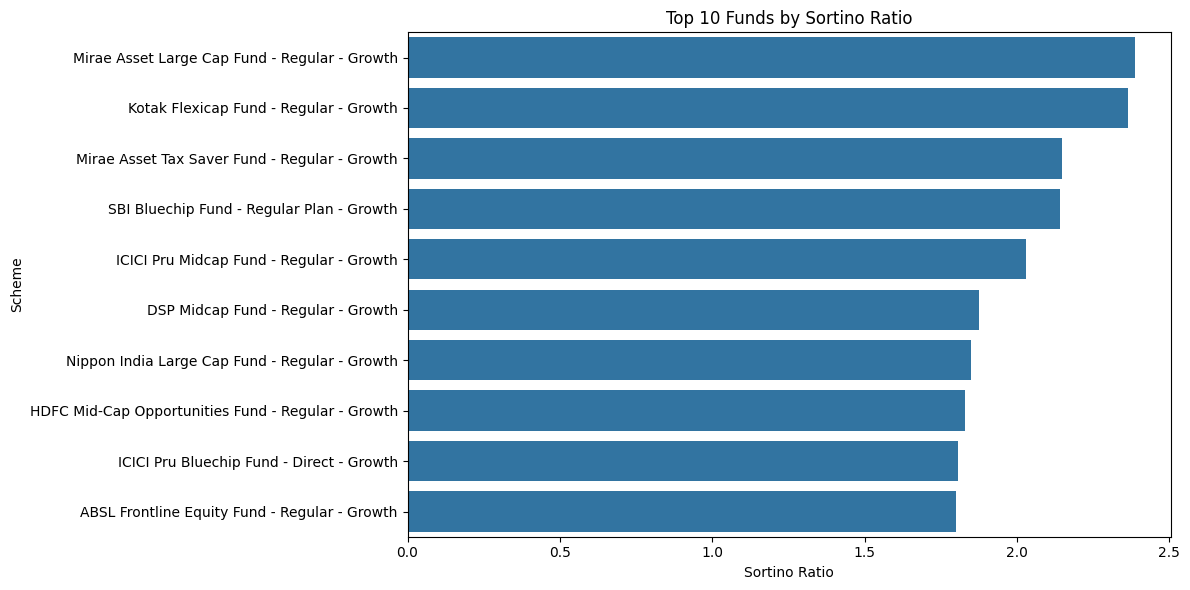

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino_df.head(10),
    x="Sortino_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../charts/sortino_ratio.png", dpi=300)

plt.show()

In [52]:
print(benchmark.head())
print(benchmark.columns.tolist())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
['date', 'index_name', 'close_value']


In [53]:
# Convert date column
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort by index and date
benchmark = benchmark.sort_values(["index_name", "date"])

# Calculate daily returns for each index
benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [54]:
# Select only NIFTY100 benchmark

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty100.shape)

nifty100.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [55]:
from scipy.stats import linregress

alpha_beta = []

for code, group in nav_history.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 20:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": regression.intercept * 252,
        "Beta": regression.slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

print(alpha_beta_df.head())

   amfi_code     Alpha      Beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289


In [56]:
alpha_beta_df = alpha_beta_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

In [57]:
import os

os.makedirs("../outputs", exist_ok=True)

alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [58]:
drawdown_results = []

for code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    # Maximum drawdown
    max_dd = group["drawdown"].min()

    # Date of maximum drawdown
    dd_date = group.loc[group["drawdown"].idxmin(), "date"]

    drawdown_results.append({
        "amfi_code": code,
        "Maximum_Drawdown": max_dd,
        "Drawdown_Date": dd_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Maximum_Drawdown,Drawdown_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [59]:
drawdown_df = drawdown_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

drawdown_df = drawdown_df[
    ["scheme_name", "amfi_code", "Maximum_Drawdown", "Drawdown_Date"]
]

drawdown_df.head()

,scheme_name,amfi_code,Maximum_Drawdown,Drawdown_Date
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,-0.247344,2022-09-15
1,HDFC Short Term Debt Fund - Regular - Growth,100025,-0.043083,2023-07-28
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,-0.162172,2022-05-12
3,ABSL Frontline Equity Fund - Regular - Growth,101206,-0.112916,2023-07-05
4,ABSL Small Cap Fund - Regular - Growth,101207,-0.354469,2026-05-11


In [60]:
worst_dd = drawdown_df.sort_values("Maximum_Drawdown").head(10)

worst_dd

,scheme_name,amfi_code,Maximum_Drawdown,Drawdown_Date
22,SBI Small Cap Fund - Direct Plan - Growth,119599,-0.525742,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,119095,-0.516778,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,101207,-0.354469,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,149324,-0.311719,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,119598,-0.287060,2025-05-14
7,UTI Mid Cap Fund - Regular - Growth,102886,-0.280011,2026-04-27
0,HDFC Top 100 Fund - Regular Plan - Growth,100016,-0.247344,2022-09-15
29,Kotak Emerging Equity Fund - Regular - Growth,120842,-0.240035,2024-10-17
11,Nippon India Small Cap Fund - Regular - Growth,118634,-0.233449,2026-02-20
15,Axis Bluechip Fund - Direct - Growth,119093,-0.217514,2023-05-22


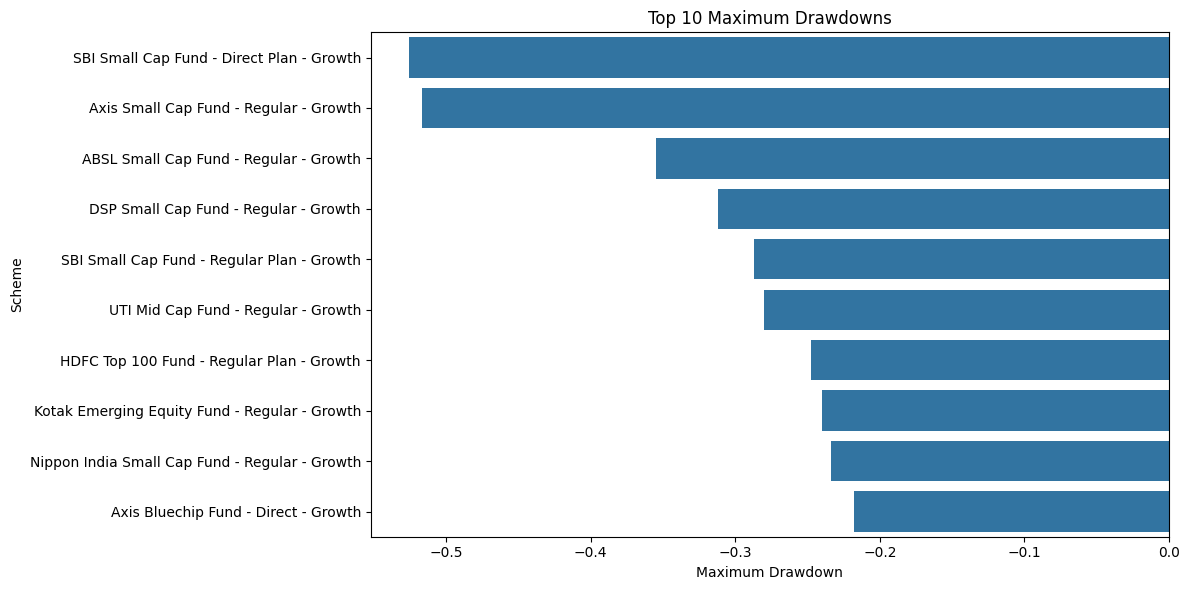

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_dd,
    x="Maximum_Drawdown",
    y="scheme_name"
)

plt.title("Top 10 Maximum Drawdowns")

plt.xlabel("Maximum Drawdown")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../charts/maximum_drawdown.png", dpi=300)

plt.show()

In [62]:
# 3-Year Return Rank
return_rank = performance[["amfi_code", "return_3yr_pct"]].copy()
return_rank["Return_Rank"] = return_rank["return_3yr_pct"].rank(ascending=False)

# Sharpe Rank
sharpe_rank = sharpe_df[["amfi_code", "Sharpe_Ratio"]].copy()
sharpe_rank["Sharpe_Rank"] = sharpe_rank["Sharpe_Ratio"].rank(ascending=False)

# Alpha Rank
alpha_rank = alpha_beta_df[["amfi_code", "Alpha"]].copy()
alpha_rank["Alpha_Rank"] = alpha_rank["Alpha"].rank(ascending=False)

# Expense Ratio Rank (Lower is Better)
expense_rank = performance[["amfi_code", "expense_ratio_pct"]].copy()
expense_rank["Expense_Rank"] = expense_rank["expense_ratio_pct"].rank(ascending=True)

# Maximum Drawdown Rank (Smaller Drawdown is Better)
drawdown_rank = drawdown_df[["amfi_code", "Maximum_Drawdown"]].copy()
drawdown_rank["Drawdown_Rank"] = drawdown_rank["Maximum_Drawdown"].rank(ascending=False)

In [63]:
scorecard = return_rank[
    ["amfi_code", "Return_Rank"]
]

scorecard = scorecard.merge(
    sharpe_rank[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_rank[["amfi_code", "Alpha_Rank"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    expense_rank[["amfi_code", "Expense_Rank"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_rank[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank
0,119551,26.0,4.0,10.0,30.5,17.0
1,119552,34.0,12.0,15.0,4.0,11.0
2,119598,1.0,14.0,1.0,21.0,36.0
3,119599,2.0,32.0,36.0,5.5,40.0
4,119120,38.0,37.0,34.0,9.0,5.0


In [64]:
scorecard["Fund_Score"] = (

    scorecard["Return_Rank"] * 0.30 +

    scorecard["Sharpe_Rank"] * 0.25 +

    scorecard["Alpha_Rank"] * 0.20 +

    scorecard["Expense_Rank"] * 0.15 +

    scorecard["Drawdown_Rank"] * 0.10

)

scorecard.head()

,amfi_code,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,119551,26.0,4.0,10.0,30.5,17.0,17.075
1,119552,34.0,12.0,15.0,4.0,11.0,17.900
2,119598,1.0,14.0,1.0,21.0,36.0,10.750
3,119599,2.0,32.0,36.0,5.5,40.0,20.625
4,119120,38.0,37.0,34.0,9.0,5.0,29.300


In [65]:
max_score = scorecard["Fund_Score"].max()

scorecard["Fund_Score"] = (
    100 -
    (
        scorecard["Fund_Score"] /
        max_score
    ) * 100
)

scorecard.head()

,amfi_code,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,119551,26.0,4.0,10.0,30.5,17.0,44.108020
1,119552,34.0,12.0,15.0,4.0,11.0,41.407529
2,119598,1.0,14.0,1.0,21.0,36.0,64.811784
3,119599,2.0,32.0,36.0,5.5,40.0,32.487725
4,119120,38.0,37.0,34.0,9.0,5.0,4.091653


In [66]:
scorecard = scorecard.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

scorecard = scorecard[
    ["scheme_name", "amfi_code", "Fund_Score"]
]

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,scheme_name,amfi_code,Fund_Score
12,ICICI Pru Midcap Fund - Regular - Growth,120505,70.540098
22,Kotak Flexicap Fund - Regular - Growth,120843,69.230769
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,65.630115
2,SBI Small Cap Fund - Regular Plan - Growth,119598,64.811784
34,Mirae Asset Large Cap Fund - Regular - Growth,148567,63.993453
39,DSP Small Cap Fund - Regular - Growth,149324,57.037643
38,DSP Midcap Fund - Regular - Growth,149323,55.155483
11,ICICI Pru Bluechip Fund - Direct - Growth,120504,53.846154
26,Axis Midcap Fund - Regular - Growth,119094,52.864157
36,Mirae Asset Tax Saver Fund - Regular - Growth,148569,47.545008


In [67]:
import os

os.makedirs("../outputs", exist_ok=True)

scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


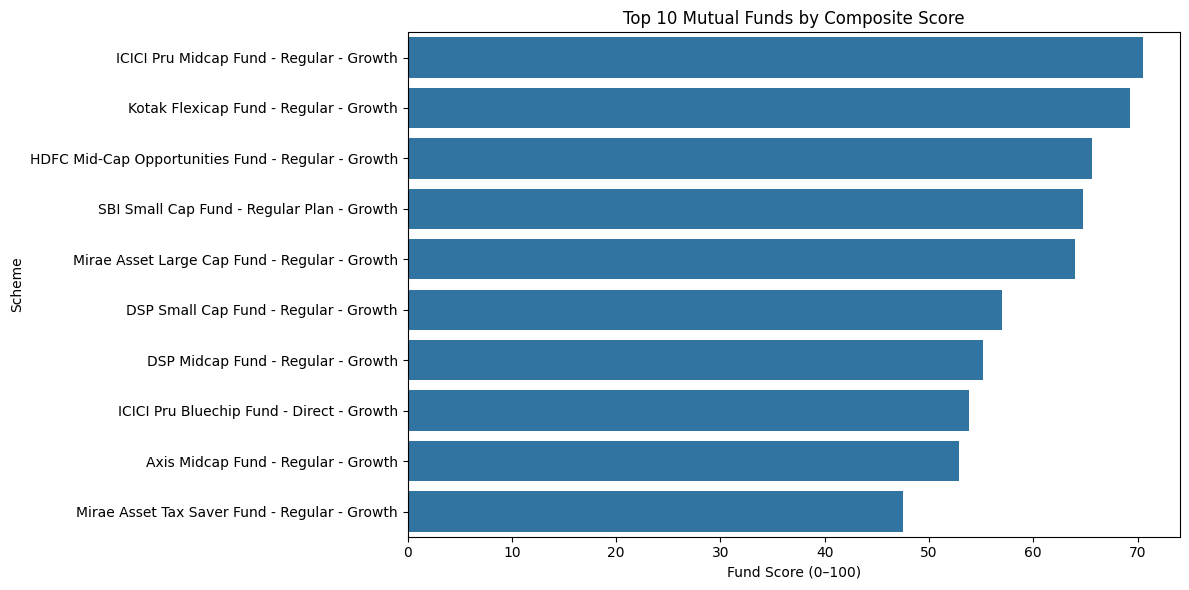

In [68]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=scorecard.head(10),
    x="Fund_Score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score (0–100)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../charts/fund_scorecard.png", dpi=300)

plt.show()

In [69]:
# Convert benchmark date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Separate NIFTY50 and NIFTY100
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Calculate daily returns
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print(nifty50.head())
print(nifty100.head())

        date index_name  close_value  benchmark_return
0 2022-01-03    NIFTY50     17492.79               NaN
1 2022-01-04    NIFTY50     17689.64          0.011253
2 2022-01-05    NIFTY50     17835.05          0.008220
3 2022-01-06    NIFTY50     17878.51          0.002437
4 2022-01-07    NIFTY50     17759.15         -0.006676
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [26]:
print("scorecard" in globals())
print("top5_codes" in globals())

False
False


In [71]:
print(scorecard.head())

                                          scheme_name  amfi_code  Fund_Score
12           ICICI Pru Midcap Fund - Regular - Growth     120505   70.540098
22             Kotak Flexicap Fund - Regular - Growth     120843   69.230769
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     100033   65.630115
2          SBI Small Cap Fund - Regular Plan - Growth     119598   64.811784
34      Mirae Asset Large Cap Fund - Regular - Growth     148567   63.993453


In [72]:
# Select top 5 funds based on Fund Score
top5 = scorecard.sort_values(
    by="Fund_Score",
    ascending=False
).head(5)

# Extract AMFI codes
top5_codes = top5["amfi_code"].tolist()

print(top5)
print(top5_codes)

                                          scheme_name  amfi_code  Fund_Score
12           ICICI Pru Midcap Fund - Regular - Growth     120505   70.540098
22             Kotak Flexicap Fund - Regular - Growth     120843   69.230769
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     100033   65.630115
2          SBI Small Cap Fund - Regular Plan - Growth     119598   64.811784
34      Mirae Asset Large Cap Fund - Regular - Growth     148567   63.993453
[120505, 120843, 100033, 119598, 148567]


In [73]:
import plotly.graph_objects as go

fig = go.Figure()

for code in top5_codes:
    temp = nav_history[nav_history["amfi_code"] == code].copy()

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["nav"],
            mode="lines",
            name=f"Fund {code}"
        )
    )

fig.add_trace(
    go.Scatter(
        x=nifty50["date"],
        y=nifty50["close_value"],
        mode="lines",
        name="NIFTY50"
    )
)

fig.add_trace(
    go.Scatter(
        x=nifty100["date"],
        y=nifty100["close_value"],
        mode="lines",
        name="NIFTY100"
    )
)

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100",
    template="plotly_white",
    width=1200,
    height=700
)

fig.show()

In [74]:
tracking_results = []

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) == 0:
        continue

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,Tracking_Error
0,120505,0.231968
1,120843,0.206425
2,100033,0.228699
3,119598,0.283881
4,148567,0.189664


In [75]:
tracking_df = tracking_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

tracking_df

,amfi_code,Tracking_Error,scheme_name
0,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth


In [76]:

import os

os.makedirs("../outputs", exist_ok=True)

tracking_df.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved successfully!")



tracking_error.csv saved successfully!


In [77]:
import os

os.makedirs("../charts", exist_ok=True)

fig.write_html("../charts/benchmark_comparison.html")

print("Benchmark comparison chart saved!")

Benchmark comparison chart saved!


In [78]:
fig.write_image("../charts/benchmark_comparison.png")